In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [17]:
#load datset
df=pd.read_csv("customer.csv")
df

,CustomerID,Age,Annual_Income,Spending_Score
0,1,28,129456,16
1,2,18,112943,23
2,3,48,76096,53
3,4,24,118546,53
4,5,25,20788,76
...,...,...,...,...
95,96,19,61277,2
96,97,49,109067,42
97,98,28,116957,67
98,99,48,24989,99


In [18]:
df

,CustomerID,Age,Annual_Income,Spending_Score
0,1,28,129456,16
1,2,18,112943,23
2,3,48,76096,53
3,4,24,118546,53
4,5,25,20788,76
...,...,...,...,...
95,96,19,61277,2
96,97,49,109067,42
97,98,28,116957,67
98,99,48,24989,99


In [61]:
## Check missing values
print(df.isnull().sum())

CustomerID        0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [62]:
#Select features
X =df[['Annual_Income','Spending_Score']]


In [67]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[['Annual_Income','Spending_Score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [69]:
print("Cluster Centers (scaled):")
print(kmeans.cluster_centers_)

Cluster Centers (scaled):
[[-1.31677153 -0.29219596]
 [ 0.47785981 -0.85565926]
 [ 0.31909249  0.91522538]]


In [70]:
# Quick look 
print(df.head(10))


   CustomerID  Age  Annual_Income  Spending_Score  Cluster
0           1   28         129456              16        1
1           2   18         112943              23        1
2           3   48          76096              53        2
3           4   24         118546              53        2
4           5   25          20788              76        0
5           6   57         110452              56        2
6           7   36         147224              55        2
7           8   18         139728              15        1
8           9   24          64437               6        1
9          10   50          99872              67        2


In [71]:
#Quick look
print(df.info(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      100 non-null    int64
 1   Age             100 non-null    int64
 2   Annual_Income   100 non-null    int64
 3   Spending_Score  100 non-null    int64
 4   Cluster         100 non-null    int32
dtypes: int32(1), int64(4)
memory usage: 3.6 KB
None


In [48]:
# Shape and summary
print(df.shape)
print(df.describe())

(100, 4)
       CustomerID        Age  Annual_Income  Spending_Score
count  100.000000  100.00000     100.000000      100.000000
mean    50.500000   41.10000   87024.140000       48.470000
std     29.011492   14.07376   35802.996985       29.133429
min      1.000000   18.00000   20788.000000        2.000000
25%     25.750000   29.00000   62458.000000       22.750000
50%     50.500000   41.50000   86563.000000       44.500000
75%     75.250000   53.25000  113626.750000       71.250000
max    100.000000   65.00000  147224.000000      100.000000


In [49]:
# Check for missing values
print(df.isnull().sum())

CustomerID        0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64


In [50]:
#Discribe Statistics
# Mean
print(df['Age'].mean(), df['Age'].median(), df['Age'].mode()[0])

41.1 41.5 18


In [51]:
#median
print(df['Annual_Income'].mean(), df['Annual_Income'].median())


87024.14 86563.0


In [52]:
#mode
print(df['Spending_Score'].mean(), df['Spending_Score'].median())

48.47 44.5


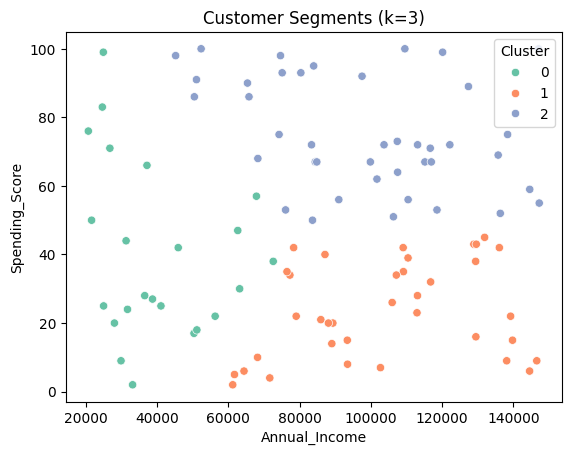

In [72]:
#
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Cluster', data=df, palette='Set2')
plt.title("Customer Segments (k=3)") 
plt.show()

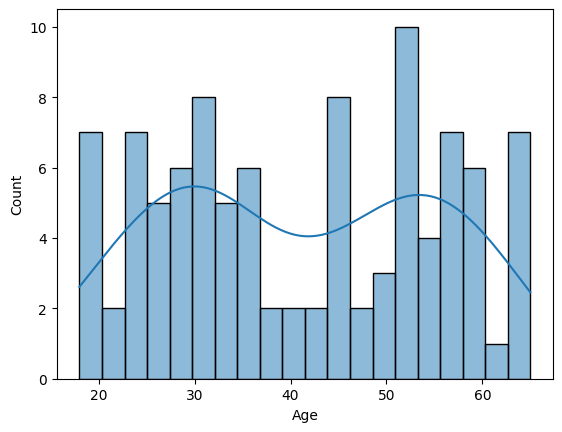

In [53]:
# Histogram of Age
sns.histplot(df['Age'], bins=20, kde=True) 
plt.show()



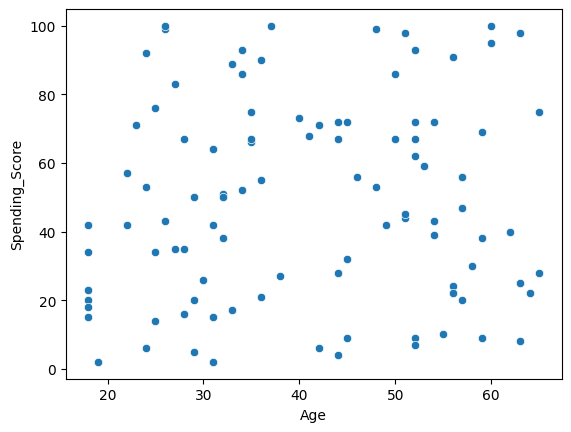

In [54]:
# Scatterplot Age vs Spending Score 
sns.scatterplot(x='Age', y='Spending_Score', data=df)
plt.show()

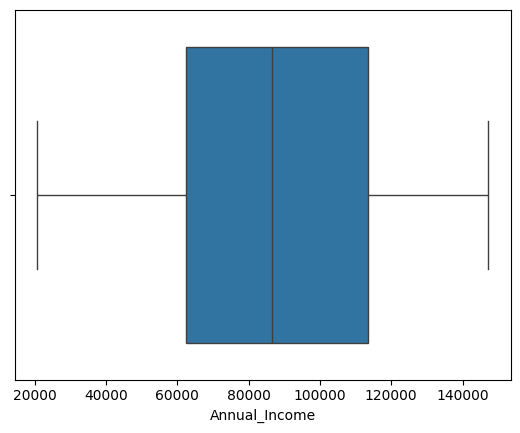

In [55]:
# Boxplot for Annual Income
sns.boxplot(x=df['Annual_Income'])
plt.show()



In [56]:
# IQR method
Q1 = df['Annual_Income'].quantile(0.25)
Q3 = df['Annual_Income'].quantile(0.75)
IQR = Q3 - Q1


In [57]:
outliers = df[(df['Annual_Income'] < Q1 - 1.5*IQR) | (df['Annual_Income'] > Q3 + 1.5*IQR)]
print(outliers)

Empty DataFrame
Columns: [CustomerID, Age, Annual_Income, Spending_Score]
Index: []


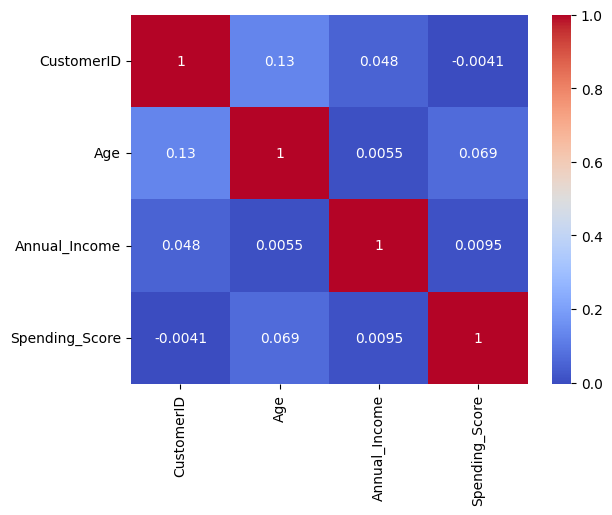

In [58]:
#Correlation matrix
corr = df.corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()